# Problem with generating coherent text

- Decoding is done iteratively and thus involves significantly more compute than simply passing inputs once through the forward pass of the model.

- The quality and diversity of the generated text depends on the choice of decoding method and associated hyperparameter.

Like other *autoregressive model* or *Casual language models* GPT-2 is trained to estimate the probability $P(y|x)$ of a sequence of tokens $y$<sub>$1$</sub>, $y$<sub>$2$</sub>, $y$<sub>$3$</sub>$...$ $y$<sub>$n$</sub> occuring in the text given an initial prompt $x =$  $x$<sub>$1$</sub>, $x$<sub>$2$</sub>, $x$<sub>$3$</sub>$...$ $x$<sub>$k$</sub>


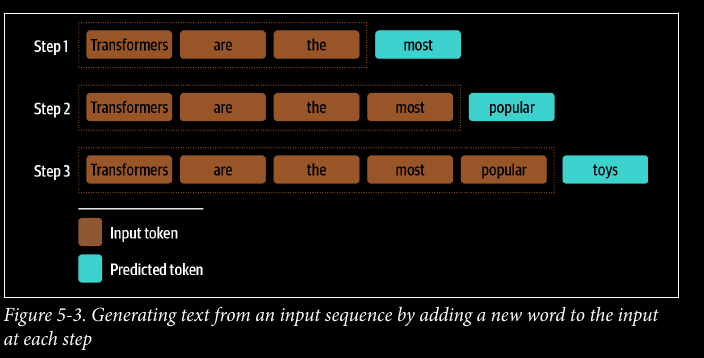

The goal of autoregressive model is to predict the next word given given the preceeding words in a sentence.

unlike BERT which utilized both past and future context to predict a masked token.

# Greedy-Search Decoding

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2-xl"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [3]:
import pandas as pd
input_txt = "Alexander the great is one"
input_ids = tokenizer(input_txt,return_tensors = "pt")["input_ids"].to("cuda")
iterations = []
n_steps = 8
choices_per_step = 5

with torch.no_grad():
  for _ in range(n_steps):
    iteration = dict()
    iteration["Input"] = tokenizer.decode(input_ids[0])
    output = model(input_ids=input_ids)
    # Select logits of the first batch and the last token and apply softmax
    next_token_logits = output.logits[0, -1, :]
    next_token_probs = torch.softmax(next_token_logits, dim=-1)
    sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True)
    # Store tokens with highest probabilities
    for choice_idx in range(choices_per_step):
      token_id = sorted_ids[choice_idx]
      token_prob = next_token_probs[token_id].cpu().numpy()
      token_choice = (
          f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)"
          )
      iteration[f"Choice {choice_idx+1}"] = token_choice
    # Append predicted next token to input
    input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
    iterations.append(iteration)
pd.DataFrame(iterations)

,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
0,Alexander the great is one,of (84.89%),who (2.12%),. (1.24%),such (1.21%),example (1.01%)
1,Alexander the great is one of,the (68.54%),those (8.49%),my (4.55%),history (3.03%),our (2.40%)
2,Alexander the great is one of the,most (39.23%),greatest (13.32%),great (5.64%),few (5.05%),best (4.69%)
3,Alexander the great is one of the most,famous (16.53%),important (6.80%),popular (6.32%),celebrated (2.48%),well (2.28%)
4,Alexander the great is one of the most famous,of (10.14%),and (10.12%),kings (8.36%),historical (5.11%),figures (4.73%)
5,Alexander the great is one of the most famous of,all (38.35%),the (29.87%),Roman (4.60%),ancient (2.66%),our (1.69%)
6,Alexander the great is one of the most famous ...,the (28.29%),Roman (9.01%),ancient (7.08%),historical (3.67%),Greek (3.61%)
7,Alexander the great is one of the most famous ...,Roman (14.21%),kings (10.27%),ancient (8.52%),Greek (8.42%),em (5.74%)


In [4]:
input_ids = tokenizer.encode(input_txt, return_tensors = "pt").to("cuda")
output = model.generate(input_ids, max_new_tokens = n_steps, do_sample = False)
print(tokenizer.decode(output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Alexander the great is one of the most famous of all the Roman


**Drawbacks** of greedy decoding: it tends to produce repetitive output sequences.
Also in context of decoding they can miss word sequences whose overall probability is higher just because high probability words happen to be proceeded by low probability one.

In [5]:
max_length = 128
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length,
do_sample=False)
print(tokenizer.decode(output_greedy[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The researchers, from the University of California, Davis, and the University of Colorado, Boulder, were conducting a study on the Andean cloud forest, which is home to the rare species of cloud forest trees.


The researchers were surprised to find that the unicorns were able to communicate with each other, and even with humans.


The researchers were surprised to find that the unicorns were able


# Beam Search decoding

Instead of decoding the token with the highest probability at each step, beam search keeps track of top-b most probable next tokens, where $b$ is the number of beams or partial hypotheses. The next set of beams are choosen by considering all possible next-token extension of the existing set and selecting the $b$ most likely extensions. The process is repeated until we reach the maximum length or an EOS token.

The mose likely token is selected by ranking b beams according to their log probabilities.

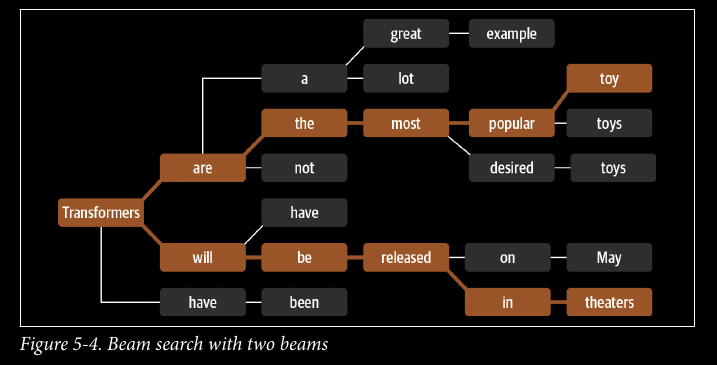

**Why do we score sequences using log probabilities instead of probabilities themselves?**

That calculating the overall probability of a sequence $P(y$<sub>$1$</sub>$,y$<sub>$2$</sub>$,...,y$<sub>$t$</sub>$|x)$ involves calculating a product of conditional probabilities $P(y$<sub>$t$</sub>$|y$<sub>$<p$</sub>$x$) is one reason. Since each conditional probabilities is a small number in range $[0,1]$, taking their product can lead to an overall probability that can underflow.



In [6]:
import torch.nn.functional as F

In [7]:
def log_probs_from_logits(logits, labels):
  logp = F.log_softmax(logits, dim = -1)
  logp_label = torch.gather(logp, 2, labels.unsqueeze(2))
  return logp_label

In [8]:
def sequence_logprob(model, labels, input_len=0):
  with torch.no_grad():
    output = model(labels)
    log_probs = log_probs_from_logits(
    output.logits[:, :-1, :], labels[:, 1:])
    seq_log_prob = torch.sum(log_probs[:, input_len:])
  return seq_log_prob.cpu().numpy()

In [9]:
logp = sequence_logprob(model, output_greedy,input_len = len(input_ids[0]))
print(tokenizer.decode(output_greedy[0]))
print(f"\nlog-prob: {logp:.2f}")

In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The researchers, from the University of California, Davis, and the University of Colorado, Boulder, were conducting a study on the Andean cloud forest, which is home to the rare species of cloud forest trees.


The researchers were surprised to find that the unicorns were able to communicate with each other, and even with humans.


The researchers were surprised to find that the unicorns were able

log-prob: -87.43


The more beams we choose the better the result potentially gets, however the generation process becomes much slower since the sequence generation are parallel

In [10]:
output_beam = model.generate(input_ids, max_length = max_length, num_beams = 5,
                             do_sample = False)
logp = sequence_logprob(model, output_beam, input_len = len(input_ids[0]))
print(tokenizer.decode(output_beam[0]))
print(f"\nlog-prob: {logp:.2f}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The discovery of the unicorns was made by a team of scientists from the University of California, Santa Cruz, and the National Geographic Society.


The scientists were conducting a study of the Andes Mountains when they discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English

log-prob: -55.23


We can see that the log probability is higher with beam search than it was with greedy decoding.

One way to stop repetitive texts in beam search is to impose an n-gram penalty with `no_repeat_ngram_size` parameter that tracks which n-grams have been seen and sets the token probability to zero if it would produce any previously seen n-gram:

In [11]:
output_beam = model.generate(input_ids, max_length = max_length, num_beams = 5,
                             do_sample = False, no_repeat_ngram_size = 1)

logp = sequence_logprob(model, output_beam, input_len = len(input_ids[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [12]:
print(tokenizer.decode(output_beam[0]))
print(f"\nlog-prob: {logp:.2f}")

In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


"We have never seen anything like this before," said biologist and lead researcher Dr Carlos Bustamante from Universidad Nacional Autónoma de México (UNAM). "It's an amazing discovery because it shows how much we still don't know about our own planet."<|endoftext|>

log-prob: -76.27


When factual correctness is less important than the diversity of the texts another way to reduce repititons is to use sampling.

# Sampling methods

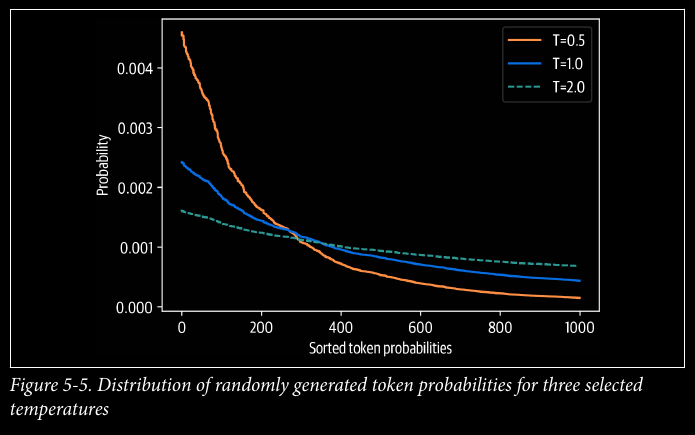

In [13]:
output_temp = model.generate(input_ids, max_length = max_length, do_sample = True,
                             temperature = 0.5, top_k = 0)
print(tokenizer.decode(output_temp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The scientists believe the unicorns are a unique group of creatures, and that they have been living in the Andes Mountains for at least 100 years.


According to the researchers, the unicorns have been living in the Andes Mountains for at least 100 years. The scientists believe that the unicorns have been living in the Andes Mountains for at least 100 years.

The scientists believe that


# Top-k and Nucleus Sampling

Another way to adjust the trade-off between coherence and diversity is to truncate the distribution of the vocabulary. This allows us to diversity freely with the temperature, but in a more limited range that excludes the word that would be too strange for the context.

The basic idea in both case is to restrict the number of possible tokens we can sample from each timestep.

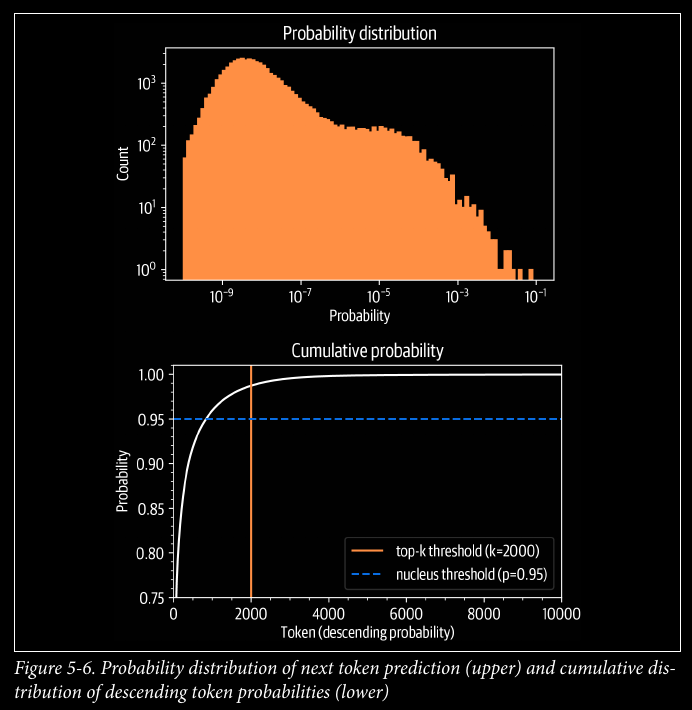

In the upper plot
we can see a histogram of the token probabilities. It has a peak around $10^−$$^8$ and a
second, smaller peak around $10^−$$^4$, followed by a sharp drop with just a handful of
tokens occurring with probability between $10^−$$^2$ and $10^−$$^1$

In the lower plot, we’ve ordered the tokens by descending probability and calculated
the cumulative sum of the first 10,000 tokens

The idea behind $top-k$ sampeling is to avoid the low probability choices by only sampling from the k tokens with the highest probability.

In [15]:
output_topk = model.generate(input_ids, max_length = max_length, do_sample = True,
                             top_k = 50)
print(tokenizer.decode(output_topk[0]))


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The results were published in the academic journal PLOS ONE.


To prove the presence of unicorns in that extreme setting - the Andean mountains - a survey was conducted. Researchers from the University of Barcelona, with assistance from the Institute of Ecology and Evolution at the Universidad de Granada found no evidence of animal life, except for the two isolated wild animals seen in 2012, but the results of


Another alternative is to use dynamic cutoff. With nucleus or top-p sampling, instead of choosing a fixed cutoff value, we set a condition of when to cut off.

In [16]:
output_topp = model.generate(input_ids, max_length = max_length, do_sample = True,
                             top_p = 0.90)
print(tokenizer.decode(output_topp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The unicorn herd is actually a part of the mountain range known as the Andes, according to scientists. The unicorns, a species that was first discovered in Peru in the 19th century, are thought to be extinct. This is a first time that scientists have found a herd of unicorns in this region, the scientists said.

The scientists, led by the University of Florida and the University
